In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import seaborn as sns
from matplotlib.patches import Rectangle

In [2]:
def show_palette(pal):
    sns.set(palette=pal)
    current_palette = sns.color_palette()
    sns.palplot(current_palette)

In [3]:

def geo_mean(iterable):
    a = np.array(iterable)
    b = a != 0
    a = a[b]
    b = a != np.inf
    a = a[b]
    return a.prod()**(1.0/len(a))

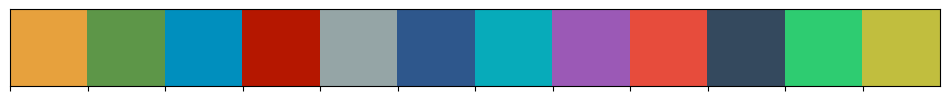

In [4]:
# flatui = ["#5d9648","#008fbe", "#b51700", "#2e578c", "#07abba","#9b59b6", "#3498db", "#95a5a6", "#e74c3c", "#34495e", "#2ecc71",]
colors = ["#e7a13d","#5d9648","#008fbe", "#b51700","#95a5a6",  "#2e578c", "#07abba","#9b59b6",   "#e74c3c", "#34495e", "#2ecc71","#c1be3e",]

sns.palplot(sns.color_palette(colors))

In [5]:
plt.rcParams['font.sans-serif'] = ['Times New Roman']

In [6]:
X_NAMES = ["TF2", "TF2-XLA", "TVM", "ANSOR", "PyTorch2", "CuDNN", "TensorRT"]
LEGENDS = ["AMD CPU", "NVIDIA GPU(Ampere Arch)", "NVIDIA GPU(Volta Arch)"]
cpu = [1.56816742557725, 2.0213421456878256, 1.913847052696851, 1.5319571716112577,1.2126125617916443, 0, 0]
cpu = [i / 1.1 for i in cpu]
gpu_amp = [3.8158259630665214, 3.1883912793329654, 2.9388554673632155, 2.096147868595006, 1.6685261438297336, 1.672718123333868, 1.233681843944061]
gpu_amp = [i / 1.1 for i in gpu_amp]
gpu_vol = [2.639546131569014, 3.053406351306822, 0, 0, 1.569547799655504, 1.2302983039721267, 1.1136403513218174]
gpu_vol = [i / 1.1 for i in gpu_vol]

findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

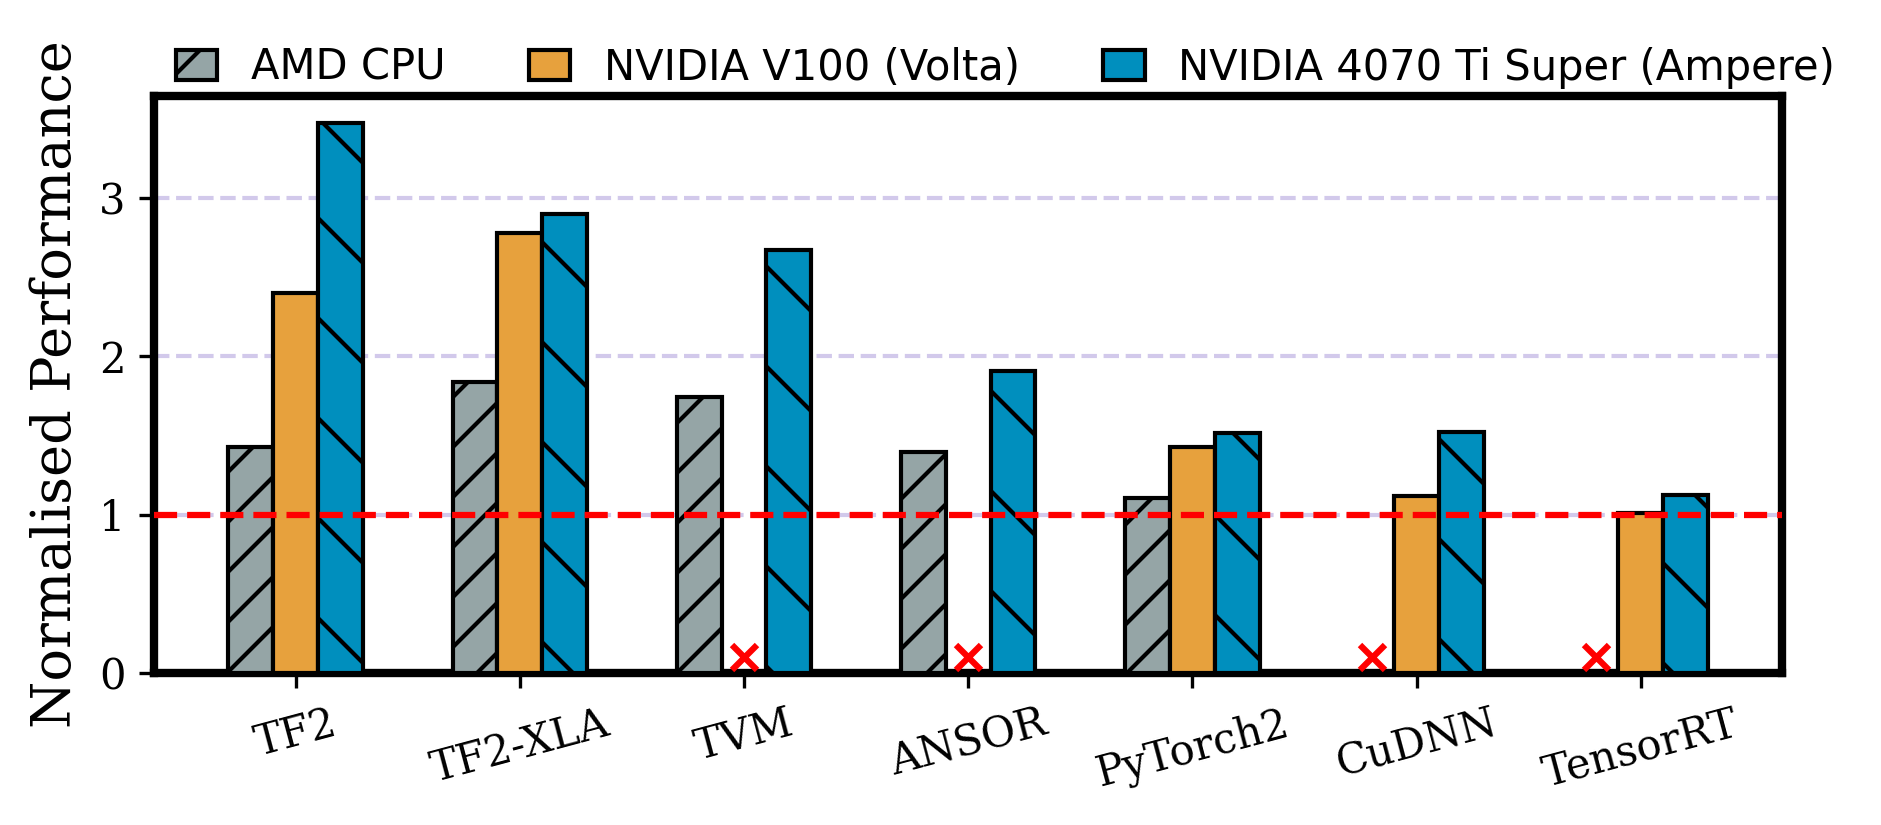

In [7]:
# 设置柱状图的位置和宽度
n = len(X_NAMES)
width = 0.2
ind = np.arange(n)
line_width = 1

# 创建柱状图
fig, ax = plt.subplots(figsize=(7,2.5), dpi=300)
rects1 = ax.bar(ind - width, cpu, width, label='AMD CPU',color=colors[4],edgecolor='black', linewidth=line_width,zorder=10, hatch='//')
rects3 = ax.bar(ind, gpu_vol, width, label='NVIDIA V100 (Volta)',color=colors[0],edgecolor='black', linewidth=line_width,zorder=10)
rects2 = ax.bar(ind + width, gpu_amp, width, label='NVIDIA 4070 Ti Super (Ampere)',color=colors[2],edgecolor='black', linewidth=line_width,zorder=10, hatch='\\')


plt.grid(axis="y", c='#d2c9eb',linewidth=line_width,linestyle = '--',zorder=0)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
# ax.set_ylim(top=1.05)

ax.axhline(y=1.0, color='r', linestyle='--', zorder=11)

# 在数据为0的地方标上红色的叉叉
for i, value in enumerate(cpu):
    if value == 0:
        ax.scatter(i - width, 0.1, color='red', marker='x', zorder = 12)
for i, value in enumerate(gpu_vol):
    if value == 0:
        ax.scatter(i, 0.1, color='red', marker='x',zorder=12)
for i, value in enumerate(gpu_amp):
    if value == 0:
        ax.scatter(i+ width, 0.1, color='red', marker='x',zorder=12)

# 设置图例的字体，ncol = 2 表示图例要放两列
plt.legend(prop={'family' : 'Times New Roman', 'size': 10}, ncol = 10,frameon=False, loc='upper left',handlelength=1,bbox_to_anchor=(-0.01, 1.15))

#设置X轴，Y轴标签的字体及大小
# x_len表示X轴的标签写在哪个坐标位置，有事可能x_len有变差，需要手动调一下他的值，不过偏差不会很大
plt.xticks(ind, X_NAMES, fontproperties='DejaVu Serif', rotation=15)
plt.yticks(fontproperties='DejaVu Serif')
# plt.margins(x=0.03)
# plt.xlabel("", fontproperties='Times New Roman',fontsize=10)
# plt.ylabel("Normalised Performance",fontproperties='DejaVu Serif')
# plt.tick_params(axis="x", which="both", pad=30)
# plt.xlabel("", fontproperties='Times New Roman',fontsize=10)
plt.ylabel("Normalised Performance",fontproperties='DejaVu Serif', fontsize=13)
# plt.tight_layout(marginw)
# plt.show()
plt.savefig("performance_on_devices.pdf",bbox_inches='tight')
